In [1]:
!mkdir -p data
!curl https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -o data/pbmc3k_filtered_gene_bc_matrices.tar.gz
!cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz
!mkdir -p write

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7443k  100 7443k    0     0  24.9M      0 --:--:-- --:--:-- --:--:-- 24.8M


In [ ]:
# !pip install scanpy

In [3]:
import pandas as pd
import scanpy as sc

In [4]:
sc.settings.verbosity = 3 # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [5]:
results_file = "write/pbmc3k.h5ad"  # the file that will store the analysis results

In [6]:
adata = sc.read_10x_mtx(
    "data/filtered_gene_bc_matrices/hg19/",  # the directory with the `.mtx` file
    var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
    cache=True,  # write a cache file for faster subsequent reading
)

... writing an h5ad cache file to speedup reading next time


In [7]:
adata.var_names_make_unique() # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`

In [8]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

## Preprocessing

normalizing counts per cell
    finished (0:00:00)


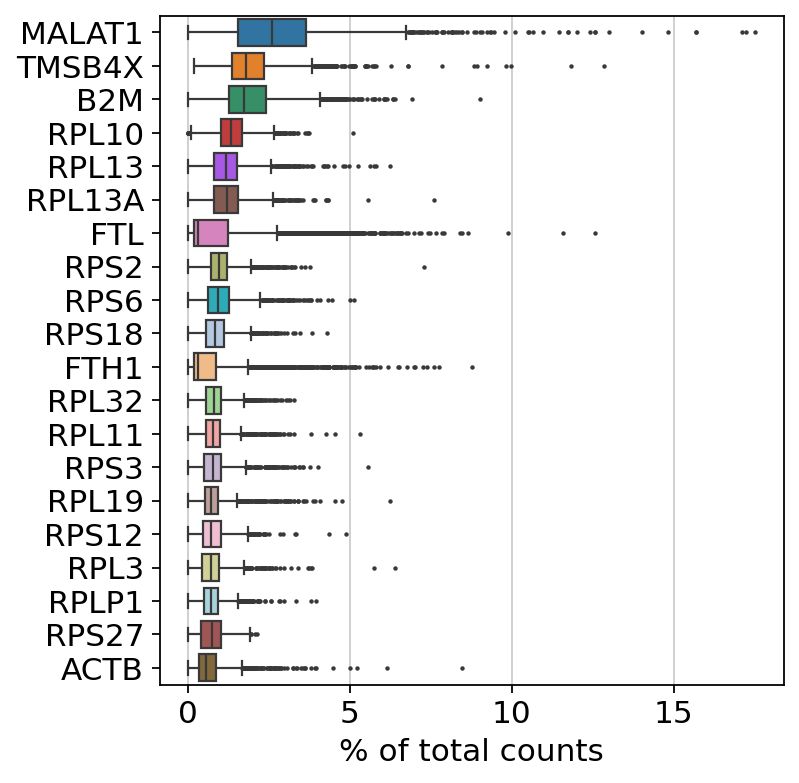

In [11]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [12]:
# basic filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

filtered out 19024 genes that are detected in less than 3 cells


In [13]:
# QC
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
)

### A violin plot of some of the computed quality measures:

 - the number of genes expressed in the count matrix

- the total counts per cell

- the percentage of counts in mitochondrial genes

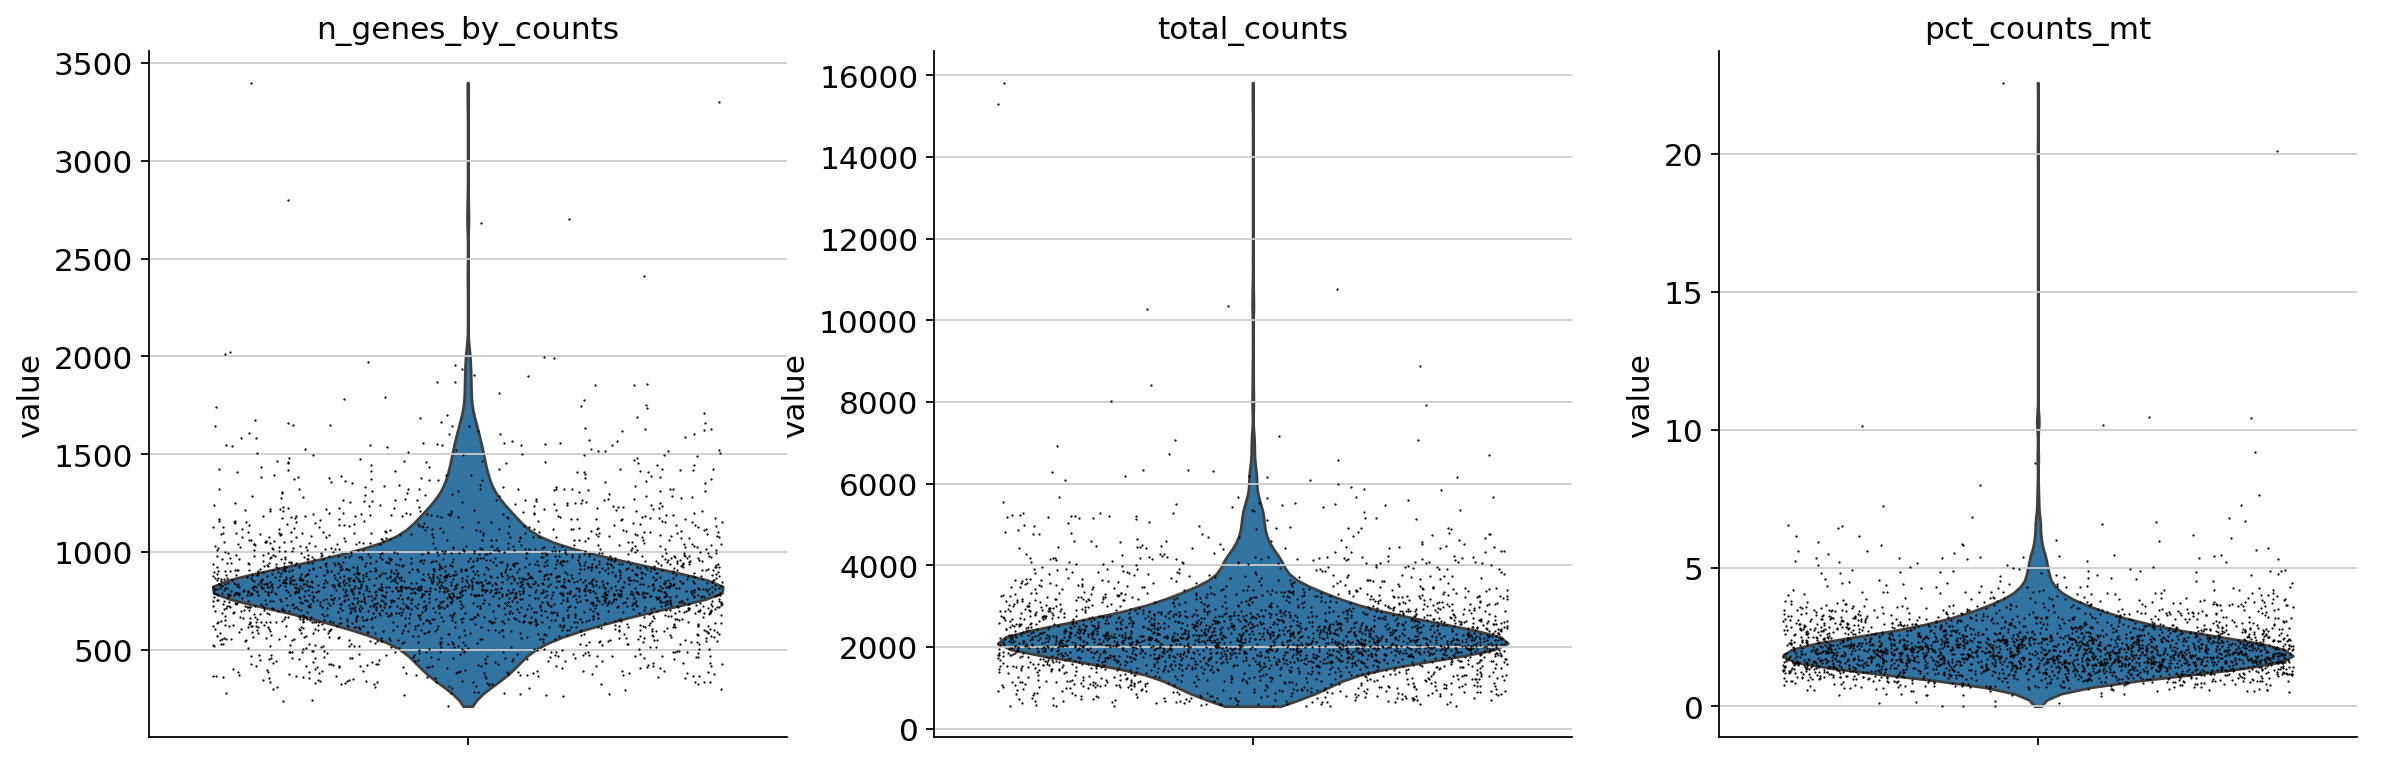

In [14]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
)

### Remove cells that have too many mitochondrial genes expressed or too many total counts:



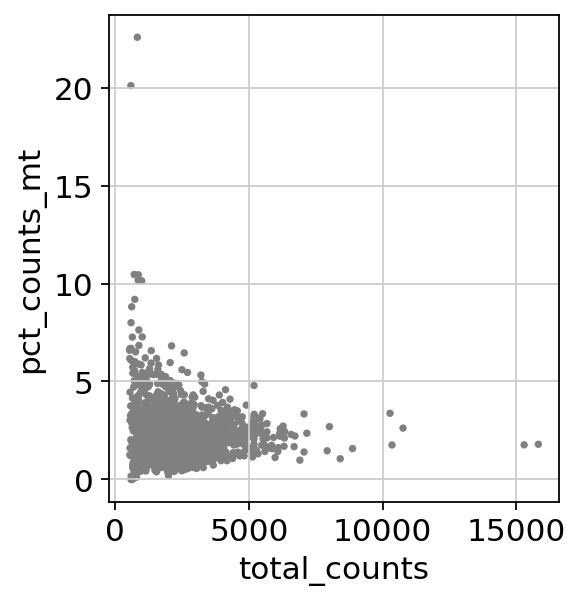

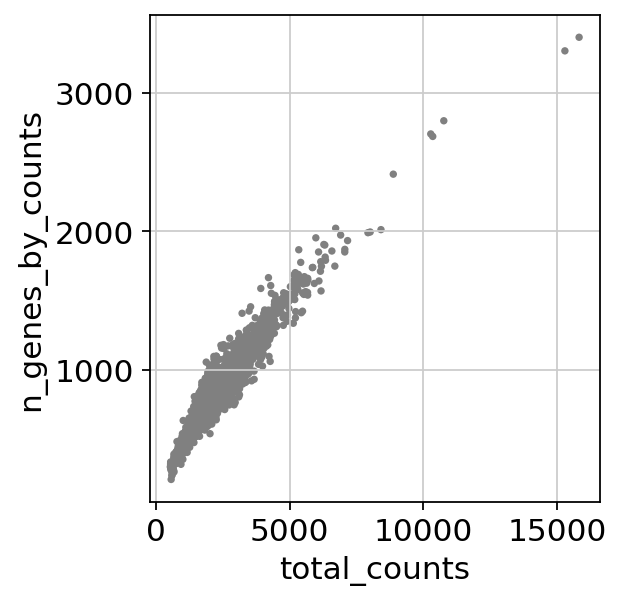

In [15]:
sc.pl.scatter(adata, x = 'total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x = 'total_counts', y='n_genes_by_counts')

In [16]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

In [17]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


## Normalize the data

In [18]:
sc.pp.log1p(adata)

## Identify high vairable genes

In [19]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


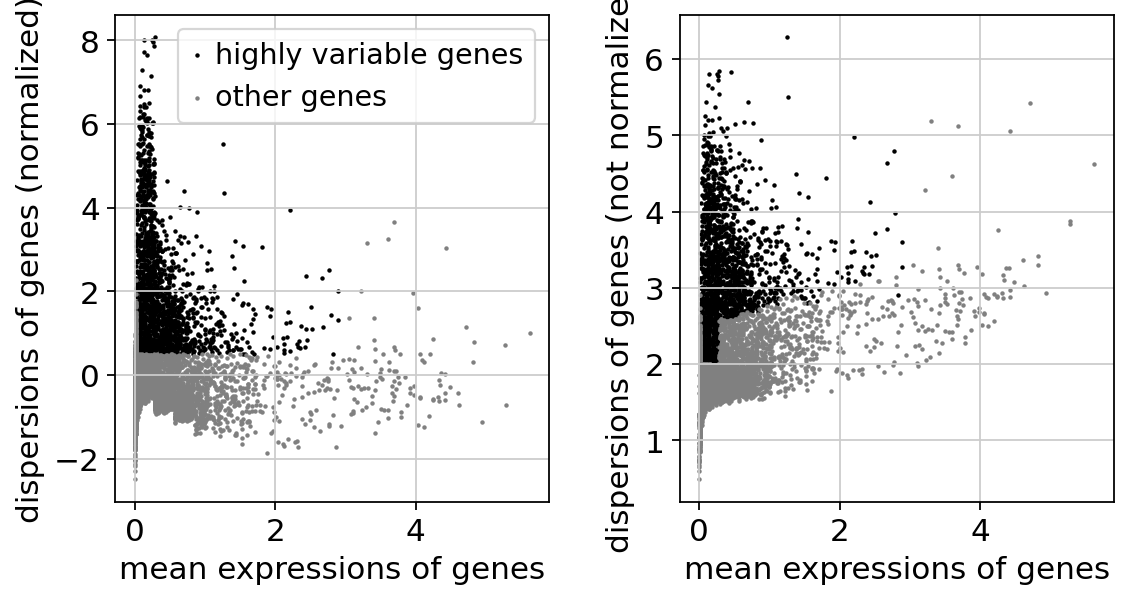

In [20]:
sc.pl.highly_variable_genes(adata)

In [21]:
adata.raw = adata.copy()

In [22]:
adata = adata[:, adata.var.highly_variable]

#### Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. Scale the data to unit variance.

In [23]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_simple.py:710: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_simple.py:648: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_simple.py:648: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:02)


#### Scale each gene to unit variance. Clip values exceeding standard deviation 10.

In [24]:
sc.pp.scale(adata, max_value=10)

## Principal component analysis

In [26]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:00:01)


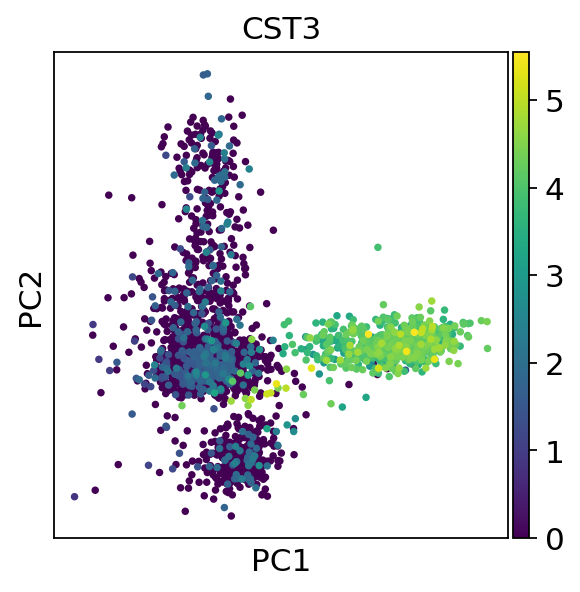

In [27]:
sc.pl.pca(adata, color='CST3')

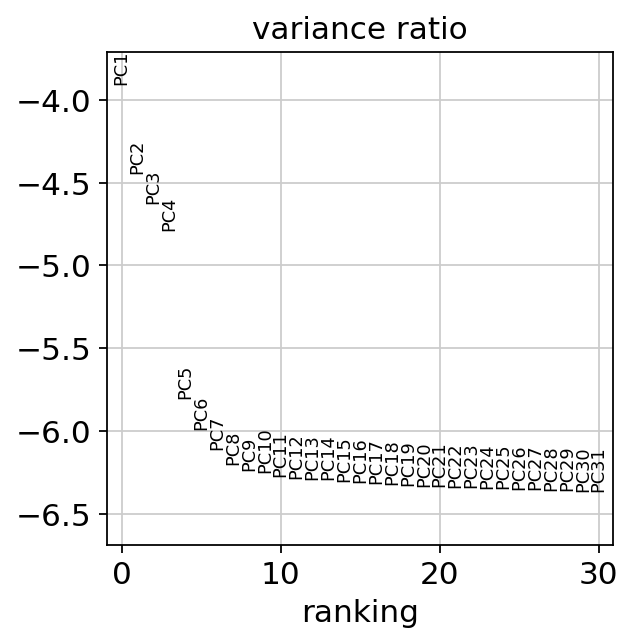

In [28]:
sc.pl.pca_variance_ratio(adata, log=True)

In [29]:
adata.write(results_file)

In [30]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

## Computing the neighborhood graph

In [31]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:37)


## Embedding the neighborhood graph

In [38]:
sc.tl.leiden(adata)     # cluster the cells
sc.tl.paga(adata)       # now build the PAGA graph
sc.pl.paga(adata, plot=False)  # optional: plot the abstracted graph
sc.tl.umap(adata, init_pos='paga')  # initialize UMAP using PAGA

running Leiden clustering


<ipython-input-38-e9ffc87f00cc>:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)     # cluster the cells


    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)


In [39]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:09)


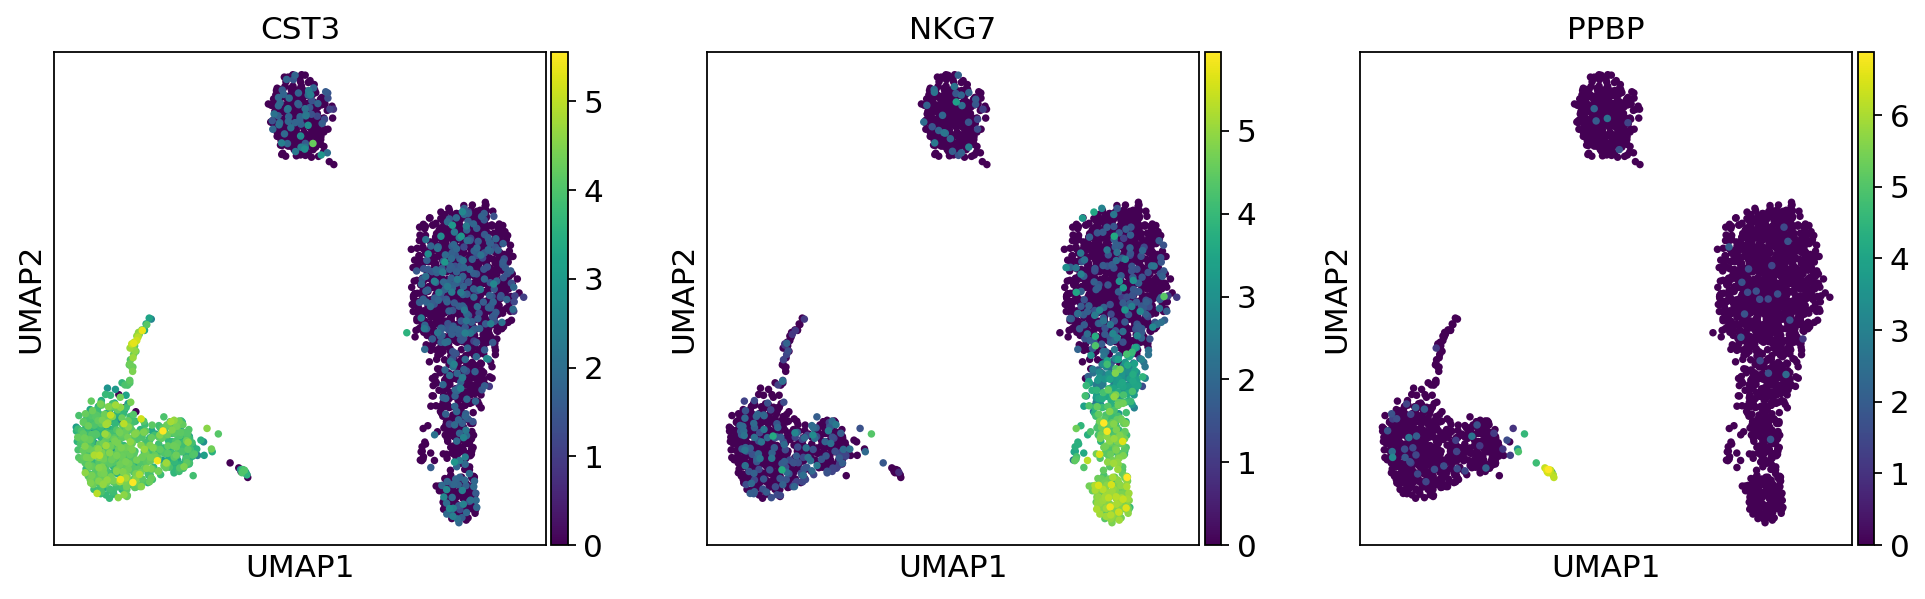

In [40]:
sc.pl.umap(adata, color=["CST3", "NKG7", "PPBP"])

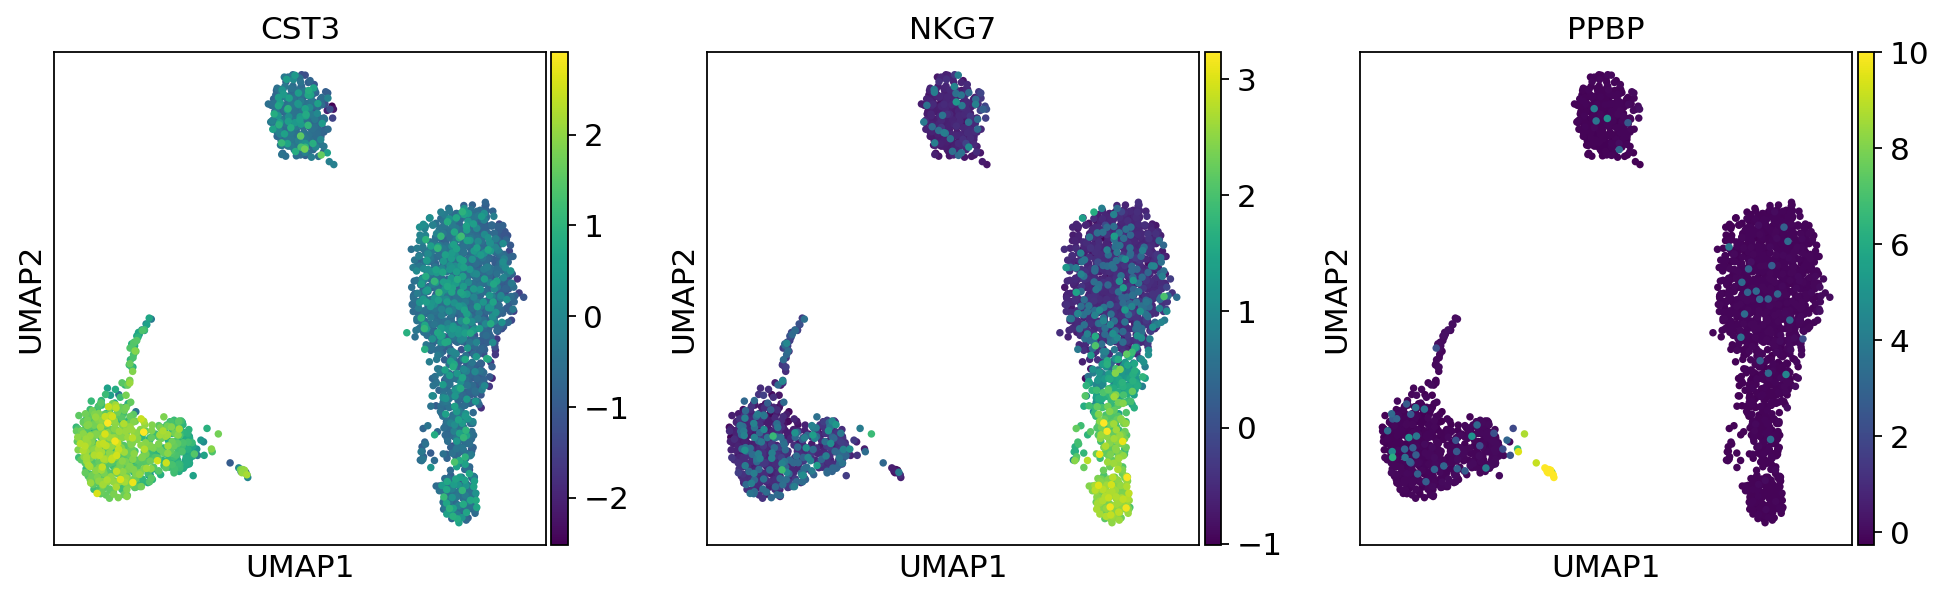

In [41]:
sc.pl.umap(adata, color=["CST3", "NKG7", "PPBP"], use_raw=False)

## Clustering the neighborhood graph

In [42]:
sc.tl.leiden(
    adata,
    resolution=0.9,
    random_state=0,
    flavor='igraph',
    n_iterations=2,
    directed = False
)

running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


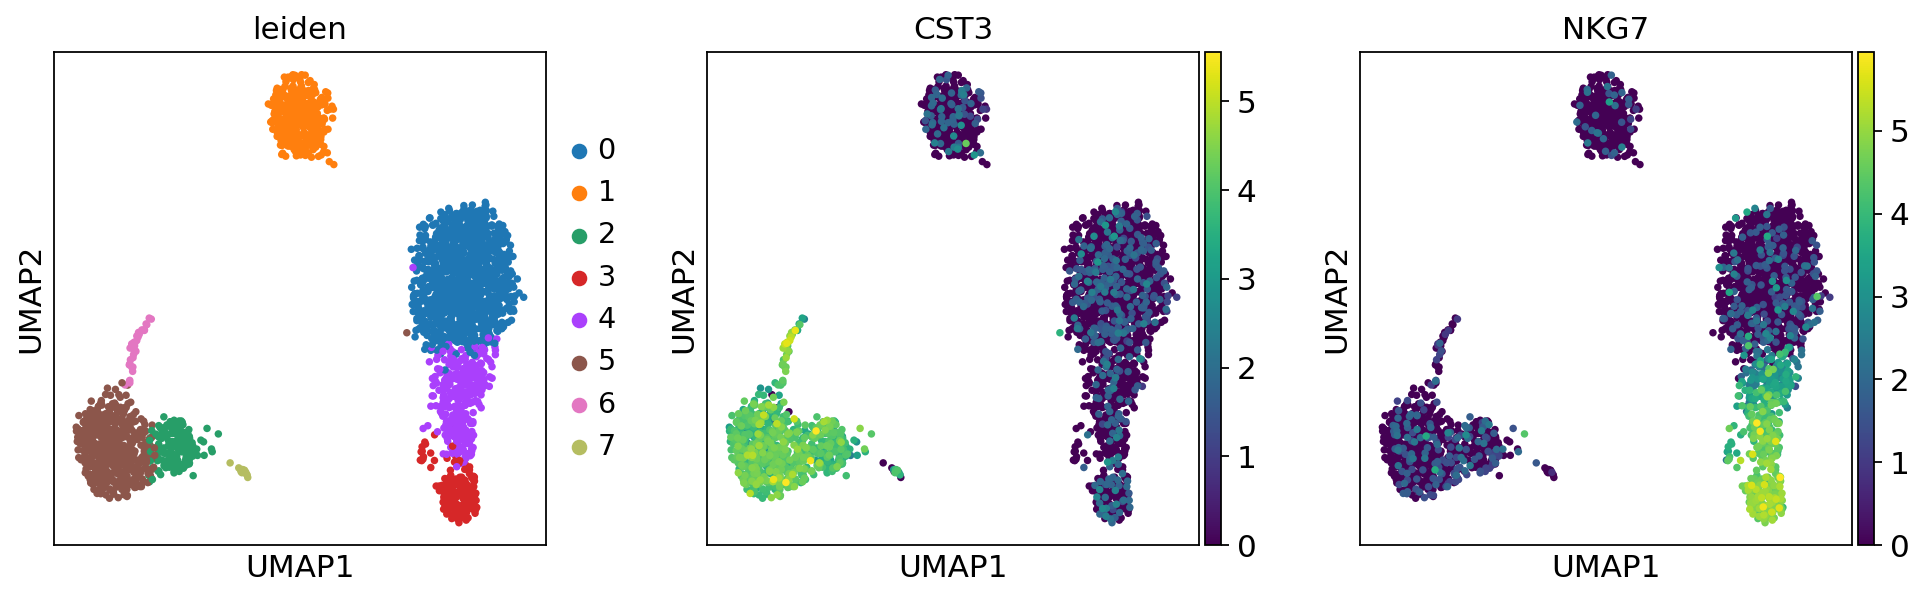

In [43]:
sc.pl.umap(adata, color=['leiden', 'CST3', 'NKG7'])

In [44]:
adata.write(results_file)

## Finding marker genes

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


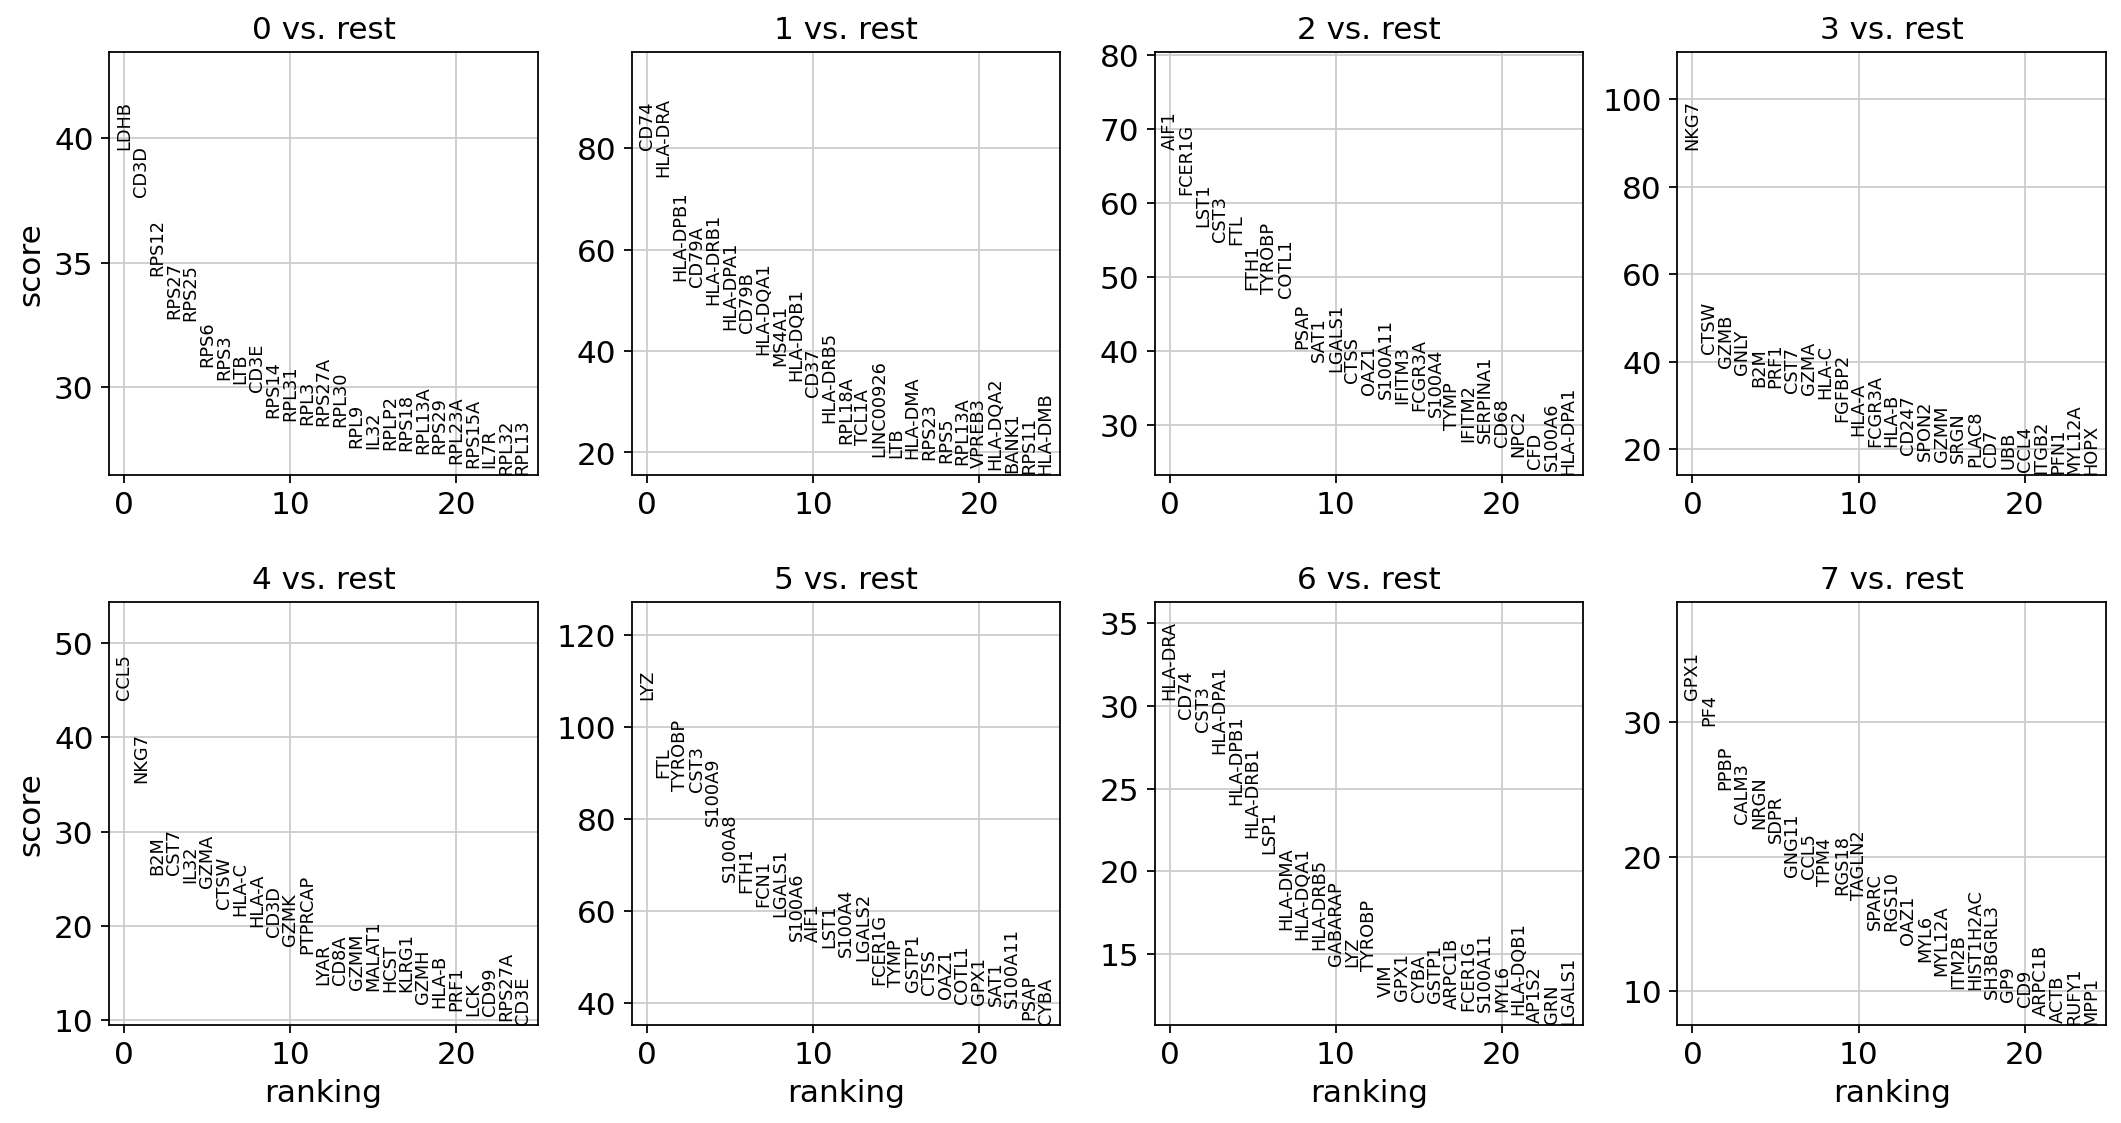

In [45]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [46]:
sc.settings.verbosity = 2

ranking genes
    finished (0:00:11)


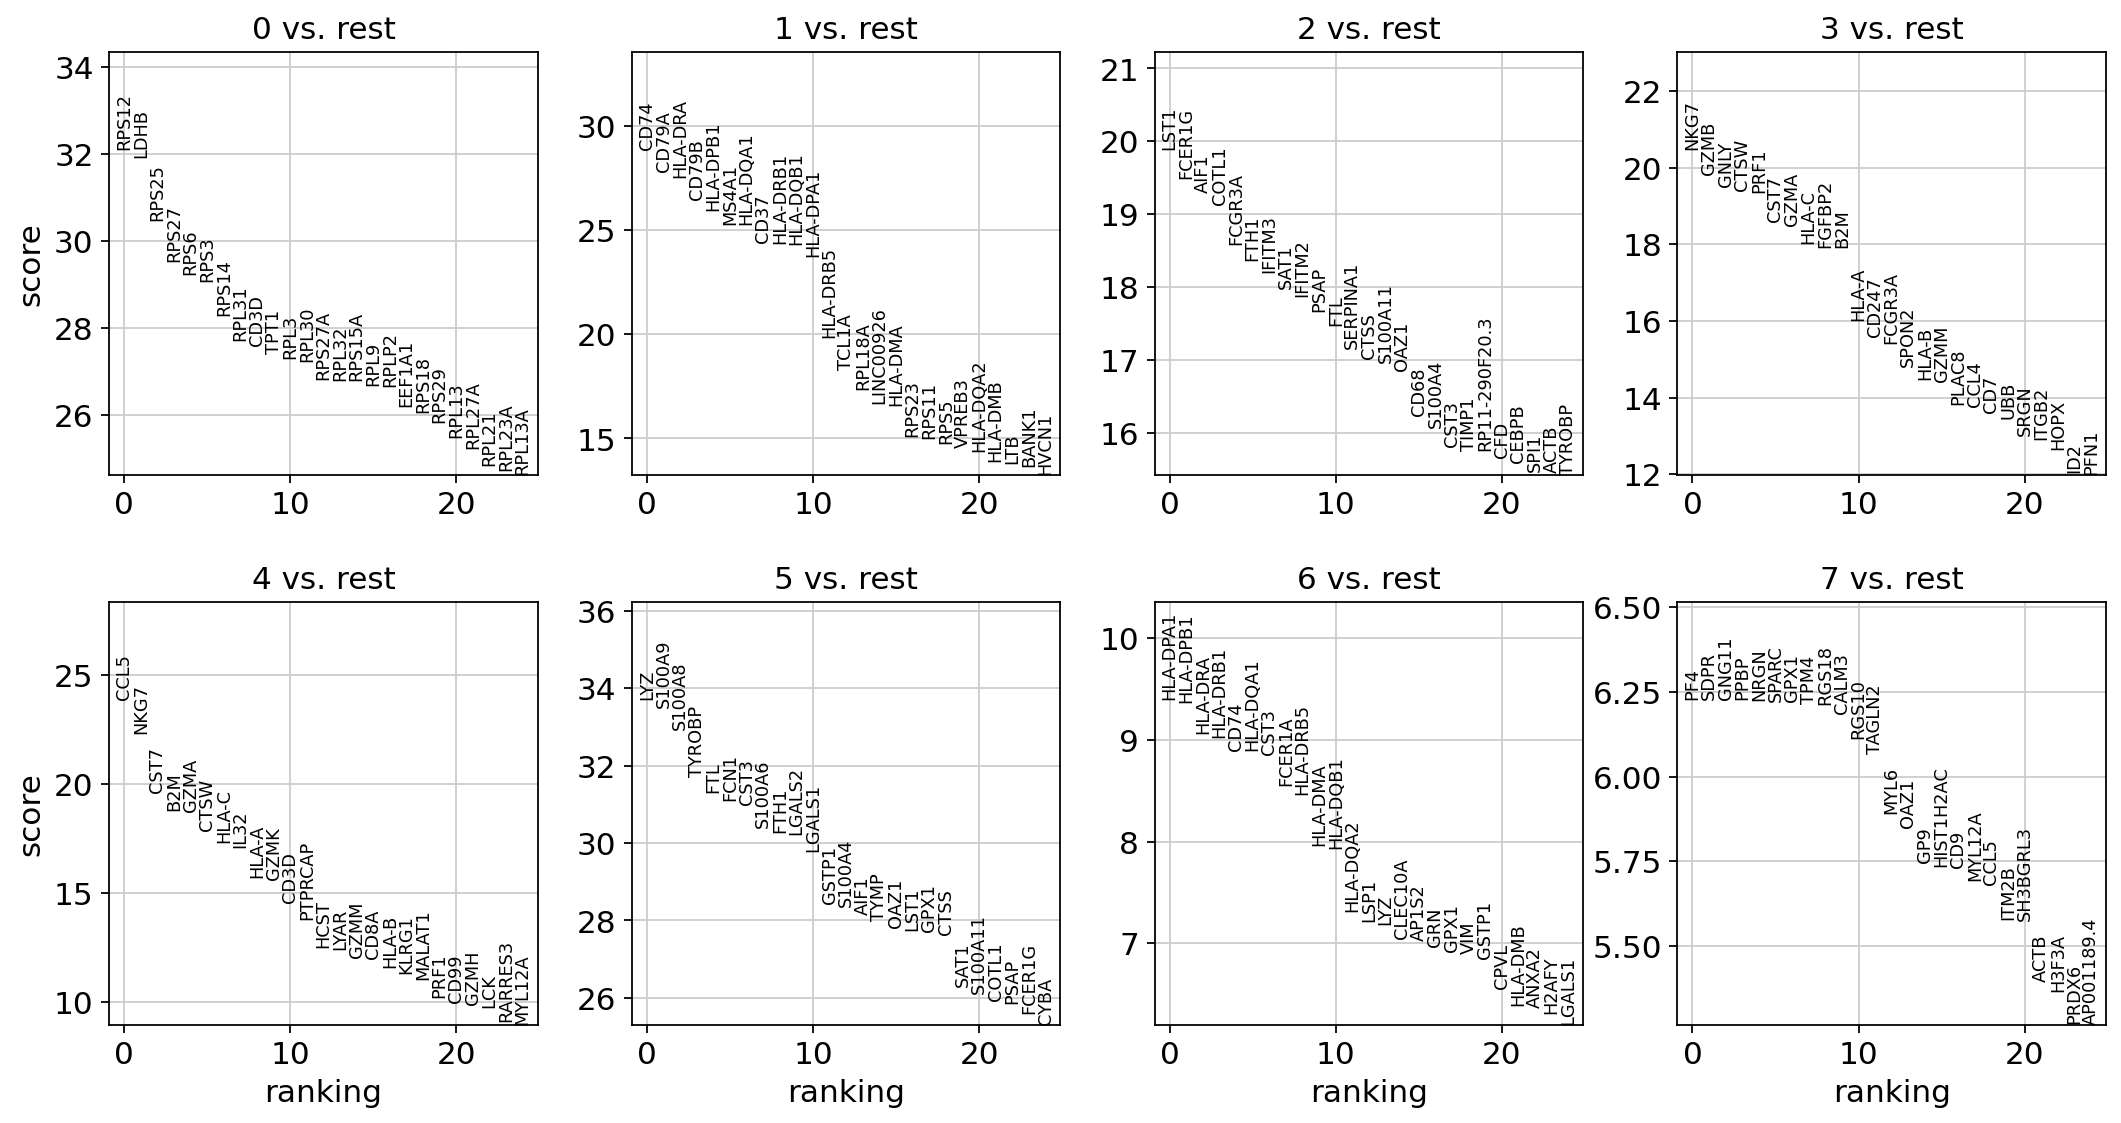

In [47]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [48]:
adata.write(results_file)

ranking genes
    finished (0:00:07)


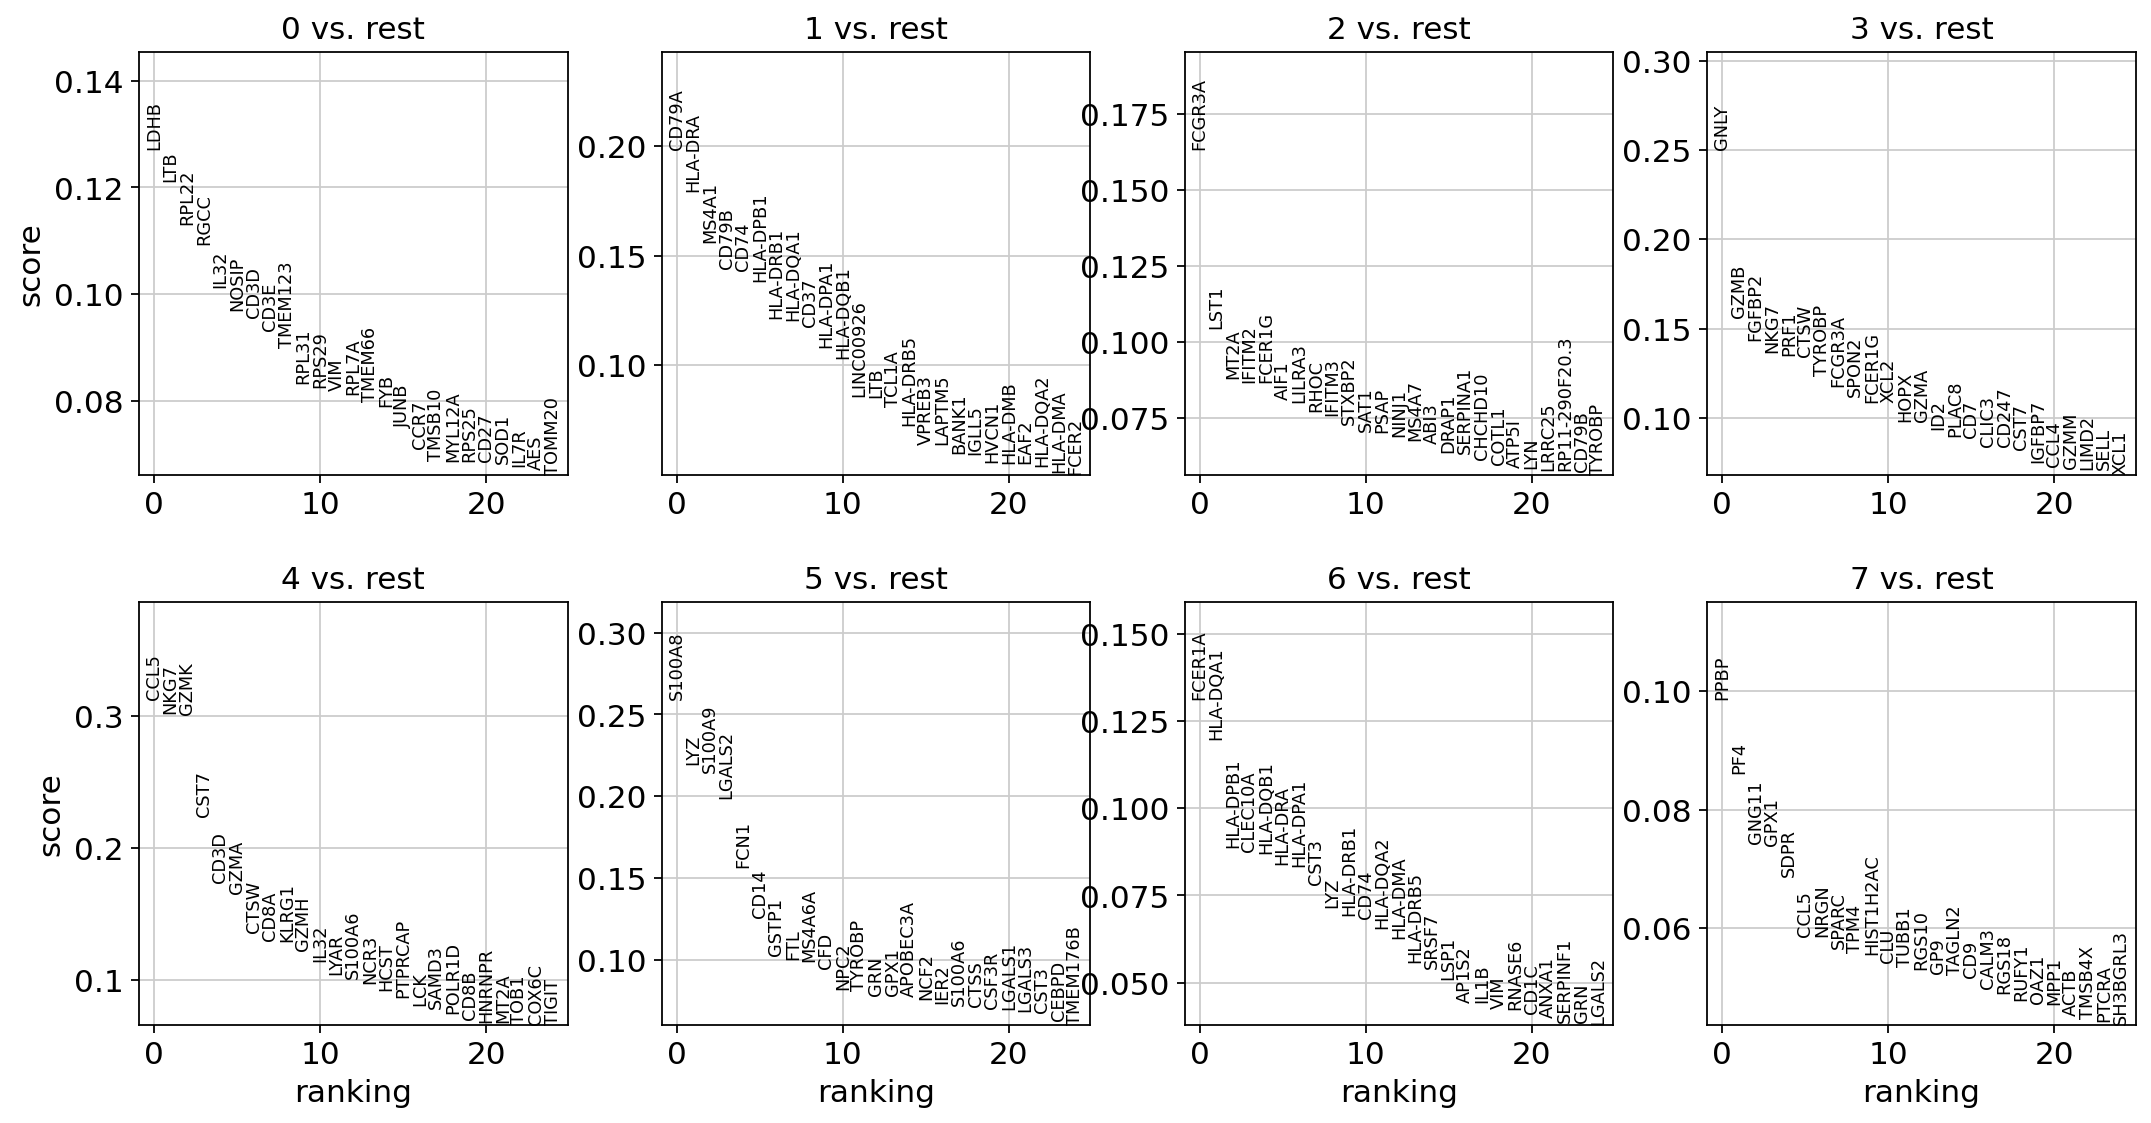

In [49]:
sc.tl.rank_genes_groups(adata, "leiden", method="logreg", max_iter=1000)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [50]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]

In [51]:
adata = sc.read(results_file)

In [52]:
pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(5)

,0,1,2,3,4,5,6,7
0,RPS12,CD74,LST1,NKG7,CCL5,LYZ,HLA-DPA1,PF4
1,LDHB,CD79A,FCER1G,GZMB,NKG7,S100A9,HLA-DPB1,SDPR
2,RPS25,HLA-DRA,AIF1,GNLY,CST7,S100A8,HLA-DRA,GNG11
3,RPS27,CD79B,COTL1,CTSW,B2M,TYROBP,HLA-DRB1,PPBP
4,RPS6,HLA-DPB1,FCGR3A,PRF1,GZMA,FTL,CD74,NRGN


In [53]:
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
pd.DataFrame(
    {
        f"{group}_{key[:1]}": result[key][group]
        for group in groups
        for key in ["names", "pvals"]
    }
).head(5)

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,5_n,5_p,6_n,6_p,7_n,7_p
0,RPS12,4.167598e-226,CD74,2.487145e-183,LST1,4.985426e-88,NKG7,3.591782e-93,CCL5,4.062586e-126,LYZ,2.844372e-249,HLA-DPA1,5.422417e-21,PF4,4.722886e-10
1,LDHB,1.794807e-223,CD79A,1.679730e-170,FCER1G,1.449472e-84,GZMB,2.033412e-87,NKG7,1.528118e-110,S100A9,2.654880e-246,HLA-DPB1,7.591860e-21,SDPR,4.733899e-10
2,RPS25,4.659461e-204,HLA-DRA,6.935111e-167,AIF1,5.833547e-83,GNLY,8.130223e-85,CST7,1.332168e-85,S100A8,8.731315e-238,HLA-DRA,1.306768e-19,GNG11,4.733899e-10
3,RPS27,9.438482e-192,CD79B,2.569135e-154,COTL1,1.261406e-81,CTSW,6.944632e-84,B2M,8.615108e-79,TYROBP,9.809633e-221,HLA-DRB1,1.865104e-19,PPBP,4.744938e-10
4,RPS6,5.767118e-188,HLA-DPB1,3.577195e-148,FCGR3A,4.610698e-77,PRF1,1.621421e-83,GZMA,1.480430e-78,FTL,3.676035e-215,CD74,5.853161e-19,NRGN,4.800511e-10


ranking genes
    finished (0:00:01)


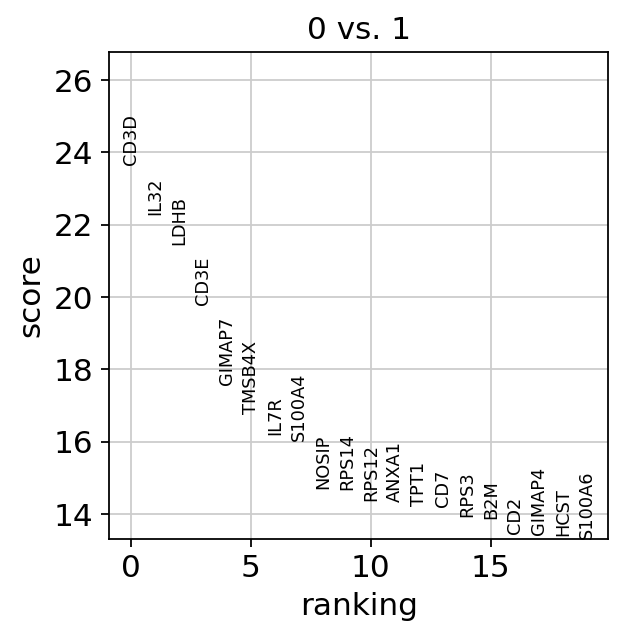

In [54]:
sc.tl.rank_genes_groups(adata, "leiden", groups=["0"], reference="1", method="wilcoxon")
sc.pl.rank_genes_groups(adata, groups=["0"], n_genes=20)

/usr/local/lib/python3.11/dist-packages/scanpy/plotting/_tools/__init__.py:1324: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


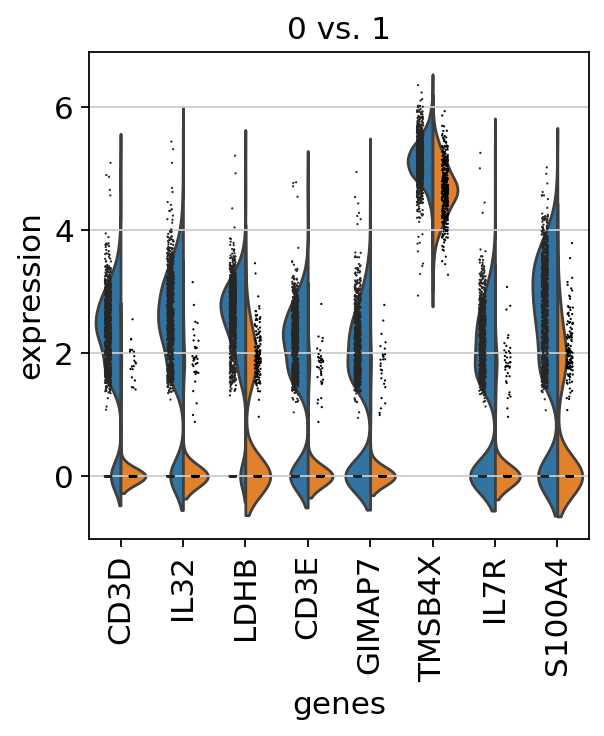

In [55]:
sc.pl.rank_genes_groups_violin(adata, groups="0", n_genes=8)

In [56]:
adata = sc.read(results_file)

/usr/local/lib/python3.11/dist-packages/scanpy/plotting/_tools/__init__.py:1324: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


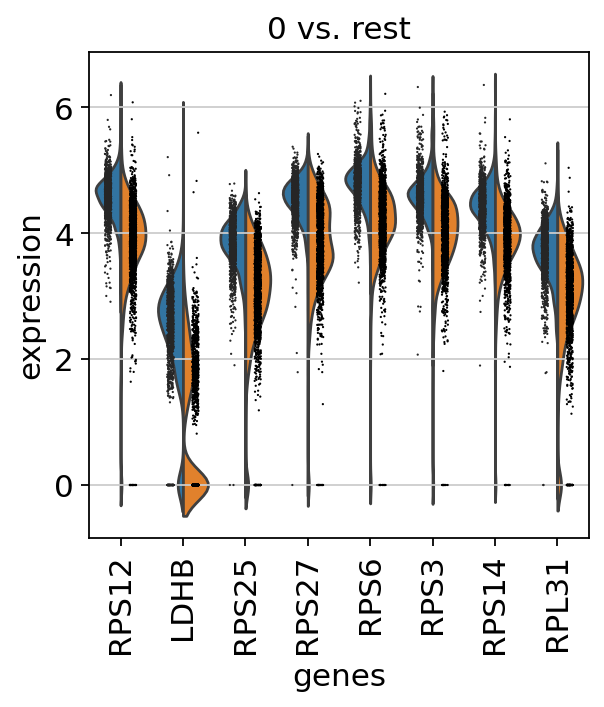

In [57]:
sc.pl.rank_genes_groups_violin(adata, groups="0", n_genes=8)

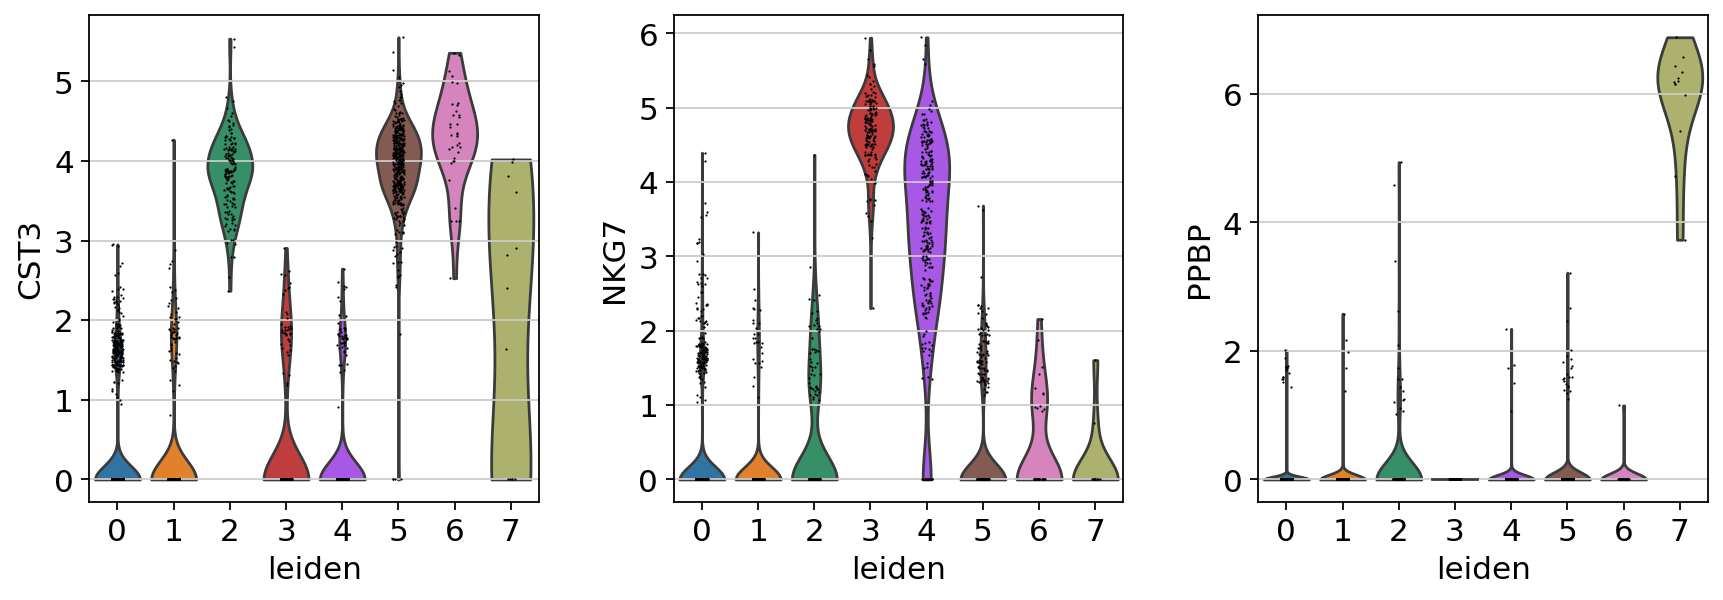

In [58]:
sc.pl.violin(adata, ["CST3", "NKG7", "PPBP"], groupby="leiden")

In [59]:
new_cluster_names = [
    "CD4 T",
    "B",
    "FCGR3A+ Monocytes",
    "NK",
    "CD8 T",
    "CD14+ Monocytes",
    "Dendritic",
    "Megakaryocytes",
]
adata.rename_categories("leiden", new_cluster_names)

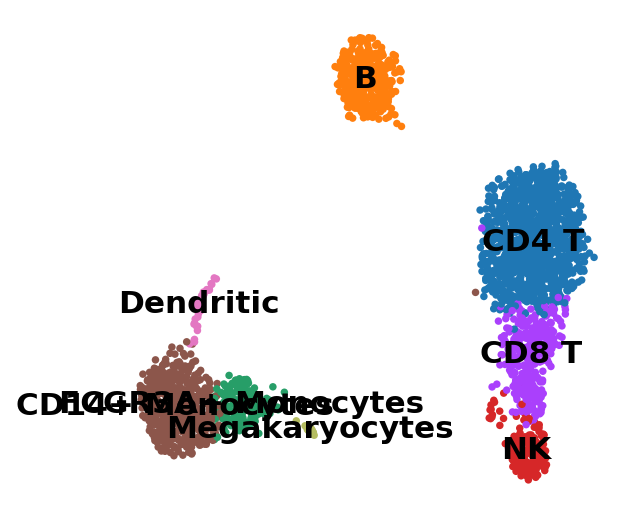

In [60]:
sc.pl.umap(
    adata, color="leiden", legend_loc="on data", title="", frameon=False, save=".pdf"
)

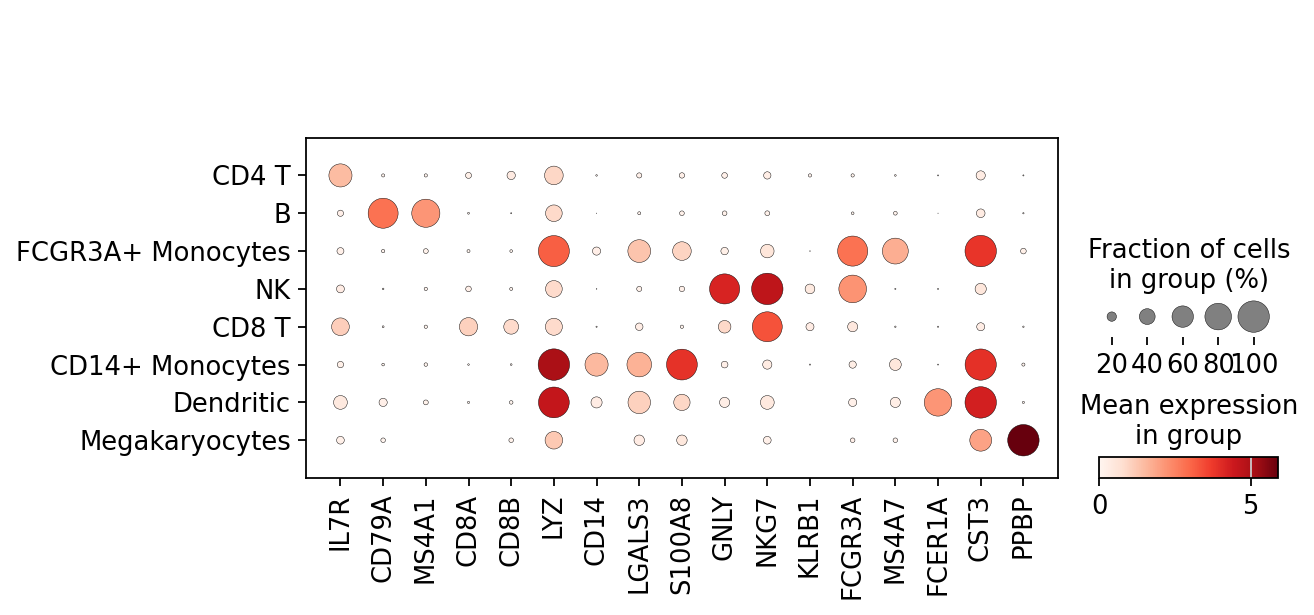

In [61]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden");

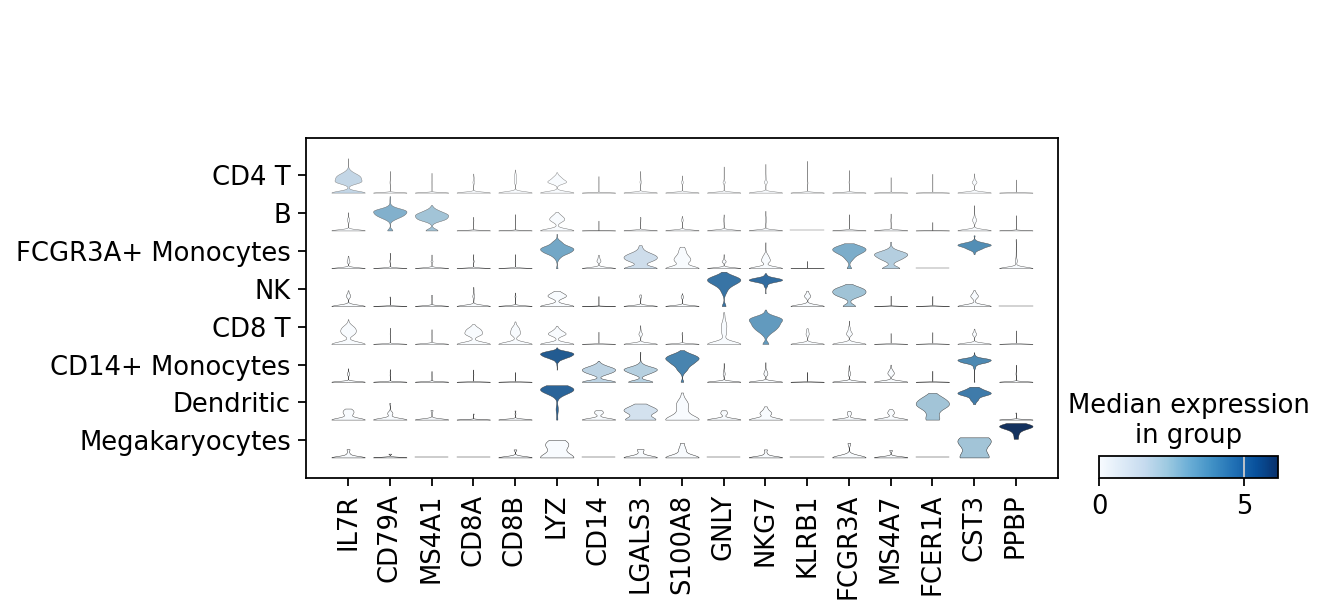

In [62]:
sc.pl.stacked_violin(adata, marker_genes, groupby="leiden");

In [63]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'